# Практическая работа: прогнозирование стоимости недвижимости

## Цель работы

Построить и исследовать модели машинного обучения для прогнозирования стоимости недвижимости.

In [1]:
import re
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Загрузка исходных данных

In [2]:
possible_paths = [Path("test_real_estate_samples.csv")]
csv_file = next((p for p in possible_paths if p.exists()), None)
if csv_file is None:
    raise FileNotFoundError("Не найден test_real_estate_samples.csv")
data = pd.read_csv(csv_file)
data_original = data.copy()
print(f"Файл: {csv_file}")
print(f"Размер датасета: {data.shape[0]} строк × {data.shape[1]} столбцов")
display(data.head())

Файл: test_real_estate_samples.csv
Размер датасета: 20 строк × 17 столбцов


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.00,İzmir/Foça/Yeniköy,NaN,Yok,"1,600,000.00",TRY
2,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"490,000.00",TRY
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.00,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,"103,600.00",TRY
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY


## 2. Первичный анализ датасета

Проверяются структура, типы данных, пропуски, дубликаты и основные статистические характеристики.

In [3]:
overview = pd.DataFrame({"Столбец": data.columns, 
                         "Тип данных": data.dtypes.astype(str).values, 
                         "Пропуски": data.isna().sum().values, 
                         "Доля пропусков, %": (data.isna().mean() * 100).round(1).values, 
                         "Уникальных значений": data.nunique(dropna=True).values})

display(overview)
print(f"Количество дубликатов: {data.duplicated().sum()}")
display(data.select_dtypes(include=np.number).describe().T)

,Столбец,Тип данных,Пропуски,"Доля пропусков, %",Уникальных значений
0,id,int64,0,0.00,20
1,type,str,0,0.00,1
2,sub_type,str,0,0.00,11
3,start_date,str,0,0.00,17
4,end_date,str,7,35.00,11
5,listing_type,int64,0,0.00,2
6,tom,int64,0,0.00,15
7,building_age,str,4,20.00,5
8,total_floor_count,str,0,0.00,6
9,floor_no,str,8,40.00,9


Количество дубликатов: 0


,count,mean,std,min,25%,50%,75%,max
id,20.00,"5,257.25","20,427.69",1.00,14.75,104.50,566.00,"91,731.00"
listing_type,20.00,1.50,0.51,1.00,1.00,1.50,2.00,2.00
tom,20.00,55.20,41.91,0.00,30.00,38.00,92.50,152.00
size,17.00,165.59,201.81,1.00,85.00,125.00,160.00,905.00
furnished,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,20.00,"380,835.00","640,312.31",750.00,"3,712.50","61,300.00","492,500.00","2,450,000.00"


## 3. Перевод данных на русский язык

* Для отчётной части создаётся отдельная русскоязычная копия таблицы. 
* Исходный `data` сохраняется без изменений.
* Географические названия адресов остаются в оригинальном виде.

In [4]:
column_translation = {"id":"Идентификатор","type":"Тип","sub_type":"Подтип",
                      "start_date":"Дата начала","end_date":"Дата окончания",
                      "listing_type":"Тип объявления","tom":"TOM","building_age":"Возраст здания",
                      "total_floor_count":"Количество этажей","floor_no":"Этаж",
                      "room_count":"Количество комнат","size":"Площадь","address":"Адрес",
                      "furnished":"Мебель","heating_type":"Тип отопления","price":"Цена","price_currency":"Валюта цены"}

value_translation = {"Konut":"Жилая недвижимость","Kooperatif":"Кооператив","Çiftlik Evi":"Фермерский дом",
                     "Daire":"Квартира","Prefabrik Ev":"Сборный дом","Yazlık":"Дача","Loft":"Лофт",
                     "Müstakil Ev":"Отдельный дом","Rezidans":"Резиденция","Villa":"Вилла","Fancoil":"Фанкойл",
                     "Yok":"Нет","Kalorifer (Doğalgaz)":"Радиаторное отопление (природный газ)","Müstakil":"Отдельный",
                     "Yüksek Giriş":"Высокий первый этаж","Bahçe katı":"Садовый этаж","20 ve üzeri":"20 и более",
                     "10-20 arası":"от 10 до 20","Satılık":"Продажа","Kiralık":"Аренда","TRY":"TRY"}

translated_data = data.copy()
for column in translated_data.columns:
    translated_data[column] = translated_data[column].map(lambda value: value_translation.get(value, value) if pd.notna(value) else value)
translated_data = translated_data.rename(columns=column_translation)
display(translated_data)

,Идентификатор,Тип,Подтип,Дата начала,Дата окончания,Тип объявления,TOM,Возраст здания,Количество этажей,Этаж,Количество комнат,Площадь,Адрес,Мебель,Тип отопления,Цена,Валюта цены
0,49,Жилая недвижимость,Кооператив,11/10/18,12/10/18,1,30,0,10,Отдельный,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Фанкойл,"300,000.00",TRY
1,506,Жилая недвижимость,Фермерский дом,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.00,İzmir/Foça/Yeniköy,NaN,Нет,"1,600,000.00",TRY
2,2,Жилая недвижимость,Квартира,2/13/19,NaN,1,14,0,20 и более,20 и более,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Фанкойл,"490,000.00",TRY
3,528,Жилая недвижимость,Сборный дом,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.00,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Нет,"103,600.00",TRY
4,109,Жилая недвижимость,Кооператив,11/10/18,1/9/19,1,60,0,10,Отдельный,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Фанкойл,"300,000.00",TRY
5,100,Жилая недвижимость,Дача,1/12/19,NaN,1,46,1,10,9,3+1,150.00,Mersin/Erdemli/Kargıpınarı,NaN,Фанкойл,"500,000.00",TRY
6,320,Жилая недвижимость,Дача,2/12/19,2/12/19,1,0,0,2,Отдельный,4+1,134.00,Balıkesir/Burhaniye/Pelitköy,NaN,Фанкойл,"1,000,000.00",TRY
7,3,Жилая недвижимость,Квартира,10/9/18,11/8/18,1,30,0,1,Высокий первый этаж,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Фанкойл,"155,000.00",TRY
8,7810,Жилая недвижимость,Лофт,12/30/18,1/29/19,1,30,NaN,4,NaN,4+1,145.00,İzmir/Konak/Akın Simav,NaN,Радиаторное отопление (природный газ),"650,000.00",TRY
9,11,Жилая недвижимость,Отдельный дом,11/13/18,11/26/18,1,13,0,1,Садовый этаж,3+1,125.00,Muğla/Bodrum/Ortakentyahşi,NaN,Фанкойл,"2,450,000.00",TRY


## 4. Исследовательский анализ данных

Изучаются распределения цены и площади, логарифм цены, связь цены с площадью, корреляции и распределение категориальных признаков.

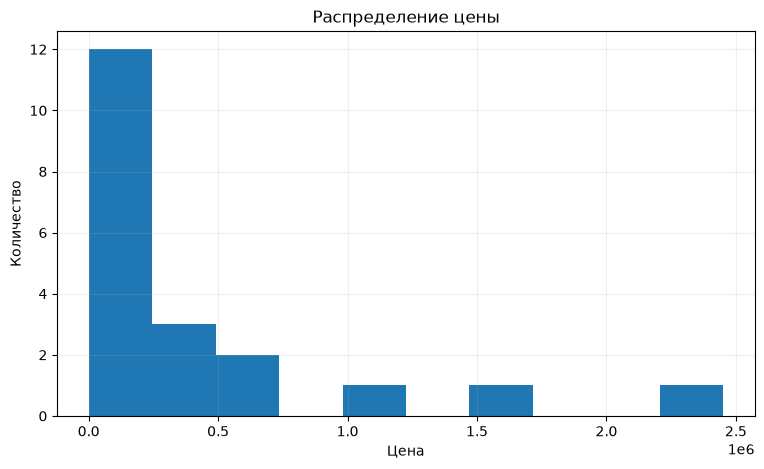

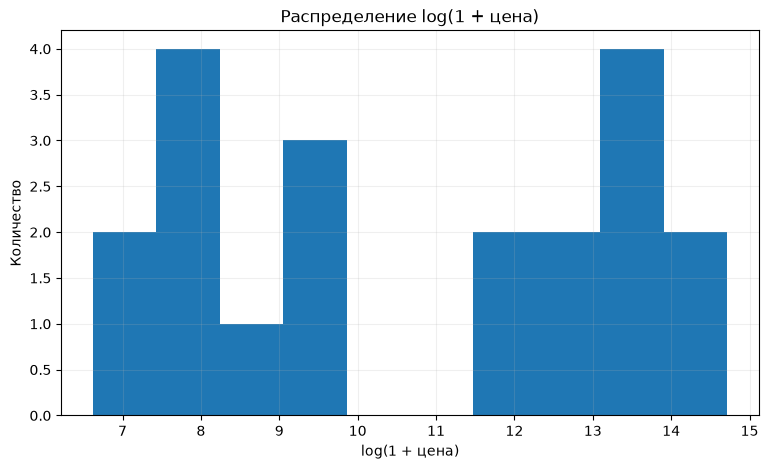

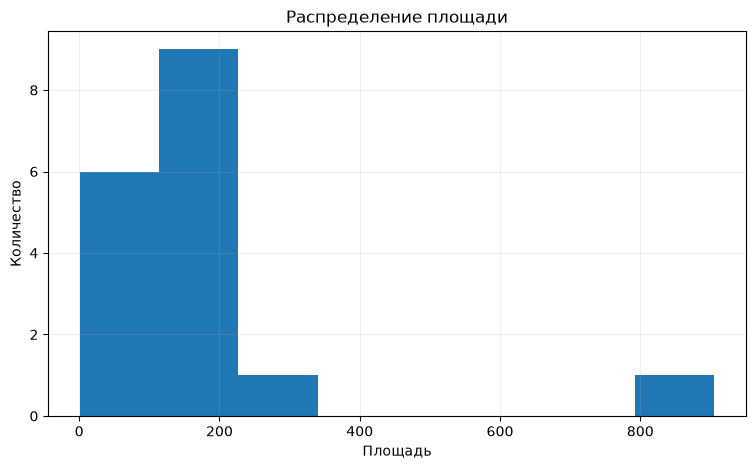

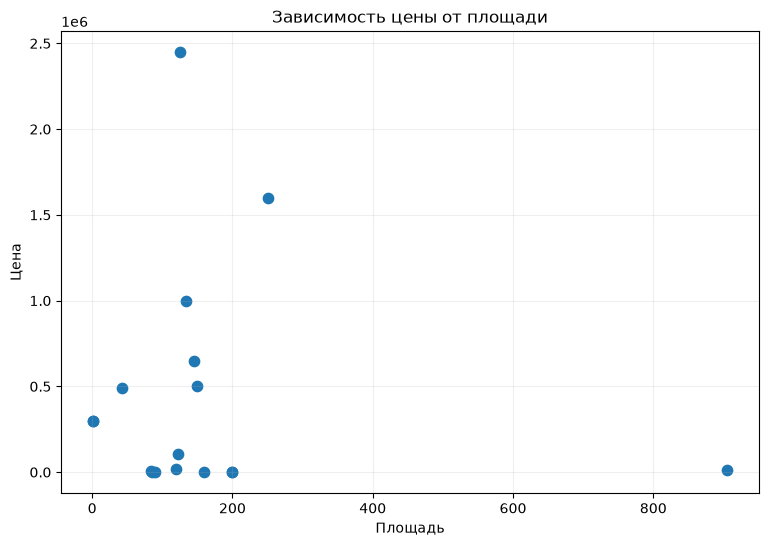

In [5]:
for title, values, xlabel in [("Распределение цены", data["price"].dropna(), "Цена"),("Распределение log(1 + цена)", np.log1p(data["price"].dropna()), "log(1 + цена)"),("Распределение площади", data["size"].dropna(), "Площадь")]:
    plt.figure(figsize=(9,5))
    plt.hist(values, bins=min(10, max(5, len(values)//2)))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Количество")
    plt.grid(alpha=0.2)
    plt.show()
plt.figure(figsize=(9,6))
plt.scatter(data["size"], data["price"], s=55)
plt.xlabel("Площадь")
plt.ylabel("Цена")
plt.title("Зависимость цены от площади")
plt.grid(alpha=0.2)
plt.show()

### 1. Корреляционная таблица

In [6]:
eda = data.copy()

def extract_number(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .str.extract(r"(\d+(?:\.\d+)?)")[0],
        errors="coerce"
    )

eda["building_age_num"] = extract_number(eda["building_age"])
eda["total_floor_num"] = extract_number(eda["total_floor_count"])
eda["floor_num"] = extract_number(eda["floor_no"])
eda["rooms_num"] = extract_number(eda["room_count"])

corr_columns = [
    "tom",
    "building_age_num",
    "total_floor_num",
    "floor_num",
    "rooms_num",
    "size",
    "price"
]

correlation = eda[corr_columns].corr()

print("Корреляционная матрица")
display(correlation.round(3))

Корреляционная матрица


,tom,building_age_num,total_floor_num,floor_num,rooms_num,size,price
tom,1.00,0.48,-0.19,-0.63,-0.01,0.44,-0.20
building_age_num,0.48,1.00,-0.42,-0.29,0.27,-0.05,-0.24
total_floor_num,-0.19,-0.42,1.00,0.62,-0.36,-0.26,-0.26
floor_num,-0.63,-0.29,0.62,1.00,-0.52,-0.36,0.32
rooms_num,-0.01,0.27,-0.36,-0.52,1.00,0.67,0.13
size,0.44,-0.05,-0.26,-0.36,0.67,1.00,-0.08
price,-0.20,-0.24,-0.26,0.32,0.13,-0.08,1.00


### 2. График корреляционной матрицы

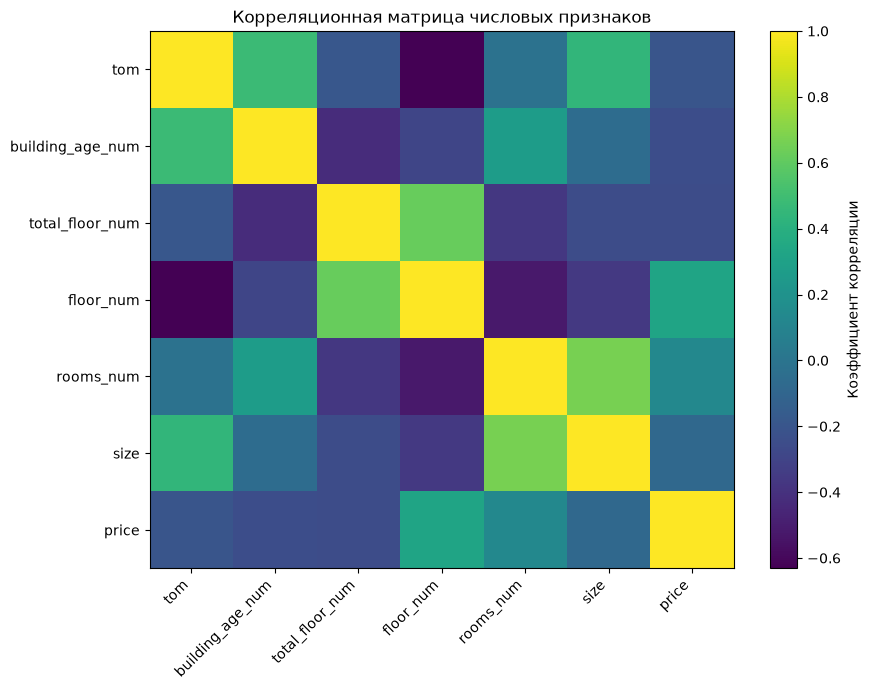

In [7]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.colorbar(label="Коэффициент корреляции")
plt.title("Корреляционная матрица числовых признаков")
plt.tight_layout()
plt.show()

### 3. Категориальные таблицы

In [8]:
print("Распределение по типу недвижимости")

type_table = (
    data["type"]
    .value_counts(dropna=False)
    .rename_axis("Тип")
    .reset_index(name="Количество")
)

display(type_table)

Распределение по типу недвижимости


,Тип,Количество
0,Konut,20


In [9]:
print("Распределение по типу объявления")

listing_table = (
    data["listing_type"]
    .value_counts(dropna=False)
    .rename_axis("Тип объявления")
    .reset_index(name="Количество")
)

display(listing_table)

Распределение по типу объявления


,Тип объявления,Количество
0,1,10
1,2,10


In [10]:
print("Распределение по типу отопления")

heating_table = (
    data["heating_type"]
    .value_counts(dropna=False)
    .rename_axis("Тип отопления")
    .reset_index(name="Количество")
)

display(heating_table)

Распределение по типу отопления


,Тип отопления,Количество
0,Fancoil,12
1,Yok,6
2,Kalorifer (Doğalgaz),1
3,Kombi (Doğalgaz),1


In [11]:
print("Распределение по валюте")

currency_table = (
    data["price_currency"]
    .value_counts(dropna=False)
    .rename_axis("Валюта")
    .reset_index(name="Количество")
)

display(currency_table)

Распределение по валюте


,Валюта,Количество
0,TRY,20


### 4. Средняя цена по подтипу

In [12]:
print("Средняя и медианная цена по подтипу недвижимости")

price_by_subtype = (
    data.groupby("sub_type", dropna=False)["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

display(price_by_subtype)

Средняя и медианная цена по подтипу недвижимости


,count,mean,median
sub_type,,,
Müstakil Ev,1,"2,450,000.00","2,450,000.00"
Çiftlik Evi,2,"809,500.00","809,500.00"
Yazlık,3,"500,400.00","500,000.00"
Loft,2,"333,000.00","333,000.00"
Kooperatif,2,"300,000.00","300,000.00"
Daire,4,"163,237.50","79,600.00"
Prefabrik Ev,1,"103,600.00","103,600.00"
Komple Bina,1,"12,500.00","12,500.00"
Villa,2,"3,600.00","3,600.00"


### 5. Средняя цена по типу объявления

In [13]:
print("Средняя и медианная цена по типу объявления")

price_by_listing = (
    data.groupby("listing_type", dropna=False)["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

display(price_by_listing)

Средняя и медианная цена по типу объявления


,count,mean,median
listing_type,,,
1,10,"754,860.00","495,000.00"
2,10,"6,810.00","3,675.00"


### Выводы по EDA

Набор очень мал, поэтому статистические выводы имеют исследовательский характер.
* Цены и площади сильно различаются, распределение цены асимметрично из-за дорогих объектов.
* Пропуски и небольшие категориальные группы требуют аккуратной предобработки.
* Логарифмирование цены снижает влияние экстремальных значений при обучении.

## 5. Подготовка признаков

Из текстовых полей извлекаются числовые признаки: возраст здания, количество этажей, этаж и количество комнат. Из адреса выделяется город.

In [14]:
model_data = data.copy()
model_data["building_age_num"] = extract_number(model_data["building_age"])
model_data["total_floor_num"] = extract_number(model_data["total_floor_count"])
model_data["floor_num"] = extract_number(model_data["floor_no"])
model_data["rooms_num"] = extract_number(model_data["room_count"])
model_data["city"] = model_data["address"].astype(str).str.split("/").str[0]
model_data["price"] = pd.to_numeric(model_data["price"], errors="coerce")
model_data["size"] = pd.to_numeric(model_data["size"], errors="coerce")
model_data["tom"] = pd.to_numeric(model_data["tom"], errors="coerce")
numeric_features = ["tom","building_age_num","total_floor_num","floor_num","rooms_num","size"]
categorical_features = ["type","sub_type","listing_type","heating_type","city"]
features = model_data[numeric_features + categorical_features].copy()
target = model_data["price"].copy()
print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)
print(f"Количество объектов: {len(features)}")

Числовые признаки: ['tom', 'building_age_num', 'total_floor_num', 'floor_num', 'rooms_num', 'size']
Категориальные признаки: ['type', 'sub_type', 'listing_type', 'heating_type', 'city']
Количество объектов: 20


## 6. Предобработка и сравнение моделей

Сравниваются Ridge, Random Forest, Extra Trees и Gradient Boosting. Числовые признаки заполняются медианой и масштабируются, категориальные — заполняются наиболее частым значением и кодируются One-Hot Encoding.

In [15]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("num", numeric_pipeline, numeric_features),("cat", categorical_pipeline, categorical_features)])
models = {"Ridge": Ridge(alpha=10.0),"Random Forest": RandomForestRegressor(n_estimators=500,max_features=0.8,min_samples_leaf=1,random_state=42,n_jobs=-1),"Extra Trees": ExtraTreesRegressor(n_estimators=500,max_features=0.9,min_samples_leaf=1,random_state=42,n_jobs=-1),"Gradient Boosting": GradientBoostingRegressor(n_estimators=300,learning_rate=0.03,max_depth=2,min_samples_leaf=2,loss="huber",random_state=42)}
pipelines = {name: Pipeline([("preprocessor", preprocessor),("regressor", model)]) for name, model in models.items()}
print("Количество моделей:", len(pipelines))

Количество моделей: 4


## 7. Повторная 5-кратная кросс-валидация

Используется RepeatedKFold: 5 блоков × 5 повторений. Для каждого разбиения прогнозируемые объекты не участвуют в обучении. Такой подход снижает зависимость результата от одного случайного разбиения, хотя при 20 наблюдениях неопределённость всё равно остаётся высокой.

In [16]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
evaluation_rows = []
oof_predictions = {}
for name, pipeline in pipelines.items():
    fold_rows = []
    prediction_sum = np.zeros(len(features))
    prediction_count = np.zeros(len(features))
    for train_idx, valid_idx in cv.split(features):
        pipeline.fit(features.iloc[train_idx], np.log1p(target.iloc[train_idx]))
        pred = np.maximum(np.expm1(pipeline.predict(features.iloc[valid_idx])), 0)
        y_valid = target.iloc[valid_idx]
        fold_rows.append({"MAE": mean_absolute_error(y_valid, pred),"RMSE": np.sqrt(mean_squared_error(y_valid, pred)),"R2": r2_score(y_valid, pred)})
        prediction_sum[valid_idx] += pred
        prediction_count[valid_idx] += 1
    fold_metrics = pd.DataFrame(fold_rows)
    evaluation_rows.append({"Модель":name,"MAE среднее":fold_metrics["MAE"].mean(),"MAE std":fold_metrics["MAE"].std(),"RMSE среднее":fold_metrics["RMSE"].mean(),"RMSE std":fold_metrics["RMSE"].std(),"R^2 среднее":fold_metrics["R2"].mean(),"R^2 std":fold_metrics["R2"].std()})
    oof_predictions[name] = prediction_sum / prediction_count
evaluation = pd.DataFrame(evaluation_rows).sort_values("R^2 среднее", ascending=False).reset_index(drop=True)
display(evaluation.round(4))

,Модель,MAE среднее,MAE std,RMSE среднее,RMSE std,R^2 среднее,R^2 std
0,Gradient Boosting,"295,193.19","241,153.38","490,847.14","394,140.18",-0.31,1.34
1,Extra Trees,"257,123.72","237,234.14","427,531.48","346,301.23",-0.35,2.72
2,Ridge,"335,735.70","232,818.27","558,609.12","392,189.62",-0.36,0.57
3,Random Forest,"261,944.67","228,745.84","444,640.19","384,557.05",-0.36,2.39


## 8. Выбор лучшей модели

Основной критерий — максимальное среднее R^2. MAE и RMSE используются как дополнительные критерии, причём меньшие значения лучше.

In [17]:
best_model_name = evaluation.loc[0, "Модель"]
best_oof_prediction = oof_predictions[best_model_name]
print(f"Лучшая модель по среднему R^2: {best_model_name}")
display(evaluation[["Модель","MAE среднее","RMSE среднее","R^2 среднее"]].round(4))

Лучшая модель по среднему R^2: Gradient Boosting


,Модель,MAE среднее,RMSE среднее,R^2 среднее
0,Gradient Boosting,"295,193.19","490,847.14",-0.31
1,Extra Trees,"257,123.72","427,531.48",-0.35
2,Ridge,"335,735.70","558,609.12",-0.36
3,Random Forest,"261,944.67","444,640.19",-0.36


## 9. Итоговая таблица для 20 объектов

In [18]:
result_table = data_original.copy()
result_table.insert(0, "ФИО", "")
result_table.insert(1, "Группа", "")
result_table["Фактическая цена"] = target.round(2)
result_table["Прогноз модели"] = np.round(best_oof_prediction, 2)
result_table["Абсолютная ошибка"] = np.round(np.abs(target.to_numpy() - best_oof_prediction), 2)
result_table["Относительная ошибка, %"] = np.round(np.where(target.to_numpy() != 0,np.abs(target.to_numpy() - best_oof_prediction) / np.abs(target.to_numpy()) * 100,np.nan),2)
display(result_table)

,ФИО,Группа,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency,Фактическая цена,Прогноз модели,Абсолютная ошибка,"Относительная ошибка, %"
0,,,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY,"300,000.00","400,352.33","100,352.33",33.45
1,,,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.00,İzmir/Foça/Yeniköy,NaN,Yok,"1,600,000.00",TRY,"1,600,000.00","352,753.92","1,247,246.08",77.95
2,,,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"490,000.00",TRY,"490,000.00","619,527.83","129,527.83",26.43
3,,,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.00,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,"103,600.00",TRY,"103,600.00","398,109.15","294,509.15",284.28
4,,,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY,"300,000.00","261,931.90","38,068.10",12.69
5,,,100,Konut,Yazlık,1/12/19,NaN,1,46,1,10,9,3+1,150.00,Mersin/Erdemli/Kargıpınarı,NaN,Fancoil,"500,000.00",TRY,"500,000.00","517,541.75","17,541.75",3.51
6,,,320,Konut,Yazlık,2/12/19,2/12/19,1,0,0,2,Müstakil,4+1,134.00,Balıkesir/Burhaniye/Pelitköy,NaN,Fancoil,"1,000,000.00",TRY,"1,000,000.00","1,519,728.40","519,728.40",51.97
7,,,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,"155,000.00",TRY,"155,000.00","730,711.50","575,711.50",371.43
8,,,7810,Konut,Loft,12/30/18,1/29/19,1,30,NaN,4,NaN,4+1,145.00,İzmir/Konak/Akın Simav,NaN,Kalorifer (Doğalgaz),"650,000.00",TRY,"650,000.00","614,062.19","35,937.81",5.53
9,,,11,Konut,Müstakil Ev,11/13/18,11/26/18,1,13,0,1,Bahçe katı,3+1,125.00,Muğla/Bodrum/Ortakentyahşi,NaN,Fancoil,"2,450,000.00",TRY,"2,450,000.00","298,982.22","2,151,017.78",87.80


## 10. Расчёт MAE, RMSE и R^2 вручную

$$MAE = \frac{1}{n}\sum |y_i-\hat y_i|$$

$$RMSE = \sqrt{\frac{1}{n}\sum(y_i-\hat y_i)^2}$$

$$R^2 = 1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$$

In [19]:
y_true = target.to_numpy(dtype=float)
y_pred = np.asarray(best_oof_prediction, dtype=float)
mae_manual = np.mean(np.abs(y_true-y_pred))
rmse_manual = np.sqrt(np.mean((y_true-y_pred)**2))
ss_res = np.sum((y_true-y_pred)**2)
ss_tot = np.sum((y_true-y_true.mean())**2)
r2_manual = 1-ss_res/ss_tot
manual_metrics = pd.DataFrame({"Метрика":["MAE","RMSE","R^2"],"Значение":[mae_manual,rmse_manual,r2_manual]})
display(manual_metrics.round(6))

,Метрика,Значение
0,MAE,"258,864.58"
1,RMSE,"587,425.49"
2,R^2,0.11


## 11. Расчёт метрик в scikit-learn

In [20]:
mae_sklearn = mean_absolute_error(y_true,y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y_true,y_pred))
r2_sklearn = r2_score(y_true,y_pred)
sklearn_metrics = pd.DataFrame({"Метрика":["MAE","RMSE","R^2"],"Значение":[mae_sklearn,rmse_sklearn,r2_sklearn]})
display(sklearn_metrics.round(6))

,Метрика,Значение
0,MAE,"258,864.58"
1,RMSE,"587,425.49"
2,R^2,0.11


## 12. Сравнение ручного и автоматического расчёта

In [21]:
metrics_comparison = pd.DataFrame({"Метрика":["MAE","RMSE","R^2"],"Вручную":[mae_manual,rmse_manual,r2_manual],"scikit-learn":[mae_sklearn,rmse_sklearn,r2_sklearn]})
metrics_comparison["Абсолютная разница"] = np.abs(metrics_comparison["Вручную"]-metrics_comparison["scikit-learn"])
display(metrics_comparison.round(8))

,Метрика,Вручную,scikit-learn,Абсолютная разница
0,MAE,"258,864.58","258,864.58",0.00
1,RMSE,"587,425.49","587,425.49",0.00
2,R^2,0.11,0.11,0.00


## 13. Анализ ошибок

Для каждого объекта рассчитываются абсолютная и относительная ошибки. Это позволяет увидеть, какие наблюдения сильнее всего влияют на качество модели.

,id,price,Прогноз модели,Абсолютная ошибка,"Относительная ошибка, %"
9,11,"2,450,000.00","298,982.22","2,151,017.78",87.80
1,506,"1,600,000.00","352,753.92","1,247,246.08",77.95
7,3,"155,000.00","730,711.50","575,711.50",371.43
6,320,"1,000,000.00","1,519,728.40","519,728.40",51.97
3,528,"103,600.00","398,109.15","294,509.15",284.28
2,2,"490,000.00","619,527.83","129,527.83",26.43
0,49,"300,000.00","400,352.33","100,352.33",33.45
4,109,"300,000.00","261,931.90","38,068.10",12.69
8,7810,"650,000.00","614,062.19","35,937.81",5.53
5,100,"500,000.00","517,541.75","17,541.75",3.51


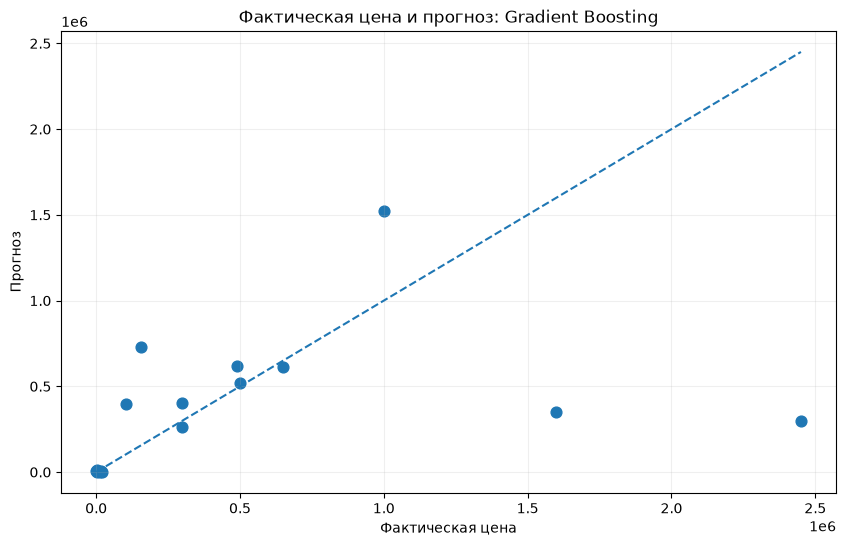

In [22]:
error_analysis = result_table[["id","price","Прогноз модели","Абсолютная ошибка","Относительная ошибка, %"]].sort_values("Абсолютная ошибка",ascending=False)
display(error_analysis)
plt.figure(figsize=(10,6))
plt.scatter(y_true,y_pred,s=60)
line_min=min(y_true.min(),y_pred.min())
line_max=max(y_true.max(),y_pred.max())
plt.plot([line_min,line_max],[line_min,line_max],linestyle="--")
plt.xlabel("Фактическая цена")
plt.ylabel("Прогноз")
plt.title(f"Фактическая цена и прогноз: {best_model_name}")
plt.grid(alpha=0.2)
plt.show()

### Интерпретация ошибок

Главное ограничение — всего 20 наблюдений. Один или два сильно дорогих объекта могут заметно изменить RMSE и R^2. Поэтому результат оценивается по таблице ошибок и повторной кросс-валидации, а не по одному показателю.

Логарифмическое преобразование целевой переменной уменьшает влияние экстремальных цен, но не устраняет его полностью. Полученные метрики относятся именно к предоставленному набору из 20 объектов и не являются гарантией качества на всём рынке недвижимости.

## 14. Важность признаков

,Признак,Важность
19,cat__listing_type_2,0.44
18,cat__listing_type_1,0.43
0,num__tom,0.04
31,cat__city_Tekirdağ,0.03
5,num__size,0.03
3,num__floor_num,0.02
4,num__rooms_num,0.01
1,num__building_age_num,0.00
17,cat__sub_type_Çiftlik Evi,0.00
16,cat__sub_type_Yazlık,0.00


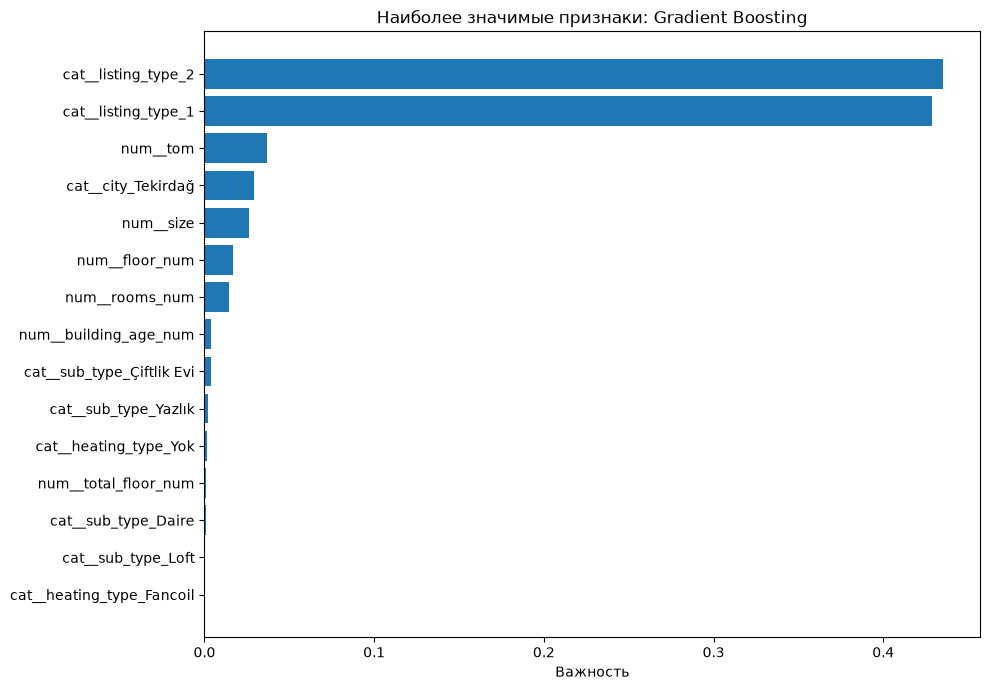

In [23]:
best_pipeline = pipelines[best_model_name]
best_pipeline.fit(features,np.log1p(target))
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_regressor = best_pipeline.named_steps["regressor"]
feature_names = fitted_preprocessor.get_feature_names_out()
importance_values = fitted_regressor.feature_importances_ if hasattr(fitted_regressor,"feature_importances_") else np.abs(fitted_regressor.coef_)
importance_table = pd.DataFrame({"Признак":feature_names,"Важность":importance_values}).sort_values("Важность",ascending=False).head(15)
display(importance_table)
plt.figure(figsize=(10,7))
plt.barh(importance_table["Признак"][::-1],importance_table["Важность"][::-1])
plt.xlabel("Важность")
plt.title(f"Наиболее значимые признаки: {best_model_name}")
plt.tight_layout()
plt.show()

## 15. Обучение итоговых моделей и сохранение

Каждый Pipeline сохраняется вместе с предобработкой. Отдельно сохраняется лучший Pipeline как `best_model.pkl`.

In [24]:
output_dir = Path(".")
saved_models = {}
for name,pipeline in pipelines.items():
    pipeline.fit(features,np.log1p(target))
    filename = name.lower().replace(" ","_")+"_model.pkl"
    joblib.dump(pipeline,output_dir/filename)
    saved_models[name]=filename
best_model_file=output_dir/"best_model.pkl"
joblib.dump(pipelines[best_model_name],best_model_file)
for name,filename in saved_models.items():
    print(f"{name}: {filename}")
print(f"Лучшая модель: {best_model_file}")

Ridge: ridge_model.pkl
Random Forest: random_forest_model.pkl
Extra Trees: extra_trees_model.pkl
Gradient Boosting: gradient_boosting_model.pkl
Лучшая модель: best_model.pkl


## 16. Формирование `result_real_estate_samples.csv`

Перед сдачей впишите ФИО и группу в переменные ниже. Последним столбцом является прогноз модели.

In [25]:
fio = "ГДР"
group = "23П-2"
final_result = data_original.copy()
final_result.insert(0,"ФИО",fio)
final_result.insert(1,"Группа",group)
final_result["predicted_price"] = np.round(best_oof_prediction,2)
result_file=output_dir/"result_real_estate_samples.csv"
final_result.to_csv(result_file,index=False,encoding="utf-8-sig")
display(final_result)
print(f"Файл сохранён: {result_file}")

,ФИО,Группа,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency,predicted_price
0,ГДР,23П-2,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY,"400,352.33"
1,ГДР,23П-2,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.00,İzmir/Foça/Yeniköy,NaN,Yok,"1,600,000.00",TRY,"352,753.92"
2,ГДР,23П-2,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.00,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,"490,000.00",TRY,"619,527.83"
3,ГДР,23П-2,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.00,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,"103,600.00",TRY,"398,109.15"
4,ГДР,23П-2,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,10,Müstakil,1+0,1.00,İzmir/Aliağa/Yenişakran,NaN,Fancoil,"300,000.00",TRY,"261,931.90"
5,ГДР,23П-2,100,Konut,Yazlık,1/12/19,NaN,1,46,1,10,9,3+1,150.00,Mersin/Erdemli/Kargıpınarı,NaN,Fancoil,"500,000.00",TRY,"517,541.75"
6,ГДР,23П-2,320,Konut,Yazlık,2/12/19,2/12/19,1,0,0,2,Müstakil,4+1,134.00,Balıkesir/Burhaniye/Pelitköy,NaN,Fancoil,"1,000,000.00",TRY,"1,519,728.40"
7,ГДР,23П-2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,"155,000.00",TRY,"730,711.50"
8,ГДР,23П-2,7810,Konut,Loft,12/30/18,1/29/19,1,30,NaN,4,NaN,4+1,145.00,İzmir/Konak/Akın Simav,NaN,Kalorifer (Doğalgaz),"650,000.00",TRY,"614,062.19"
9,ГДР,23П-2,11,Konut,Müstakil Ev,11/13/18,11/26/18,1,13,0,1,Bahçe katı,3+1,125.00,Muğla/Bodrum/Ortakentyahşi,NaN,Fancoil,"2,450,000.00",TRY,"298,982.22"


Файл сохранён: result_real_estate_samples.csv


# Итоговый вывод

В работе исследованы 20 объектов недвижимости, выполнены EDA и подготовка признаков, сравнены несколько алгоритмов регрессии и выбрана лучшая модель по результатам повторной кросс-валидации.

MAE, RMSE и R^2 рассчитаны вручную и средствами scikit-learn. Полученные значения должны совпадать с учётом округления. Итоговая таблица содержит прогнозы для всех 20 объектов.